In [59]:
print("hellow EDA")

hellow EDA


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk 

In [27]:
df = pd.read_csv('D:/Workspace/Development/Playground/UndergraduateProject/data/ai4i2020.csv')
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [28]:
df.shape

(10000, 14)

In [29]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [30]:
print(df.describe())

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

In [31]:
print(df["Machine failure"].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [32]:
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


# بررسی مقادیر گم‌شده (Missing Values)

In [33]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


# بررسی توزیع Machine failure

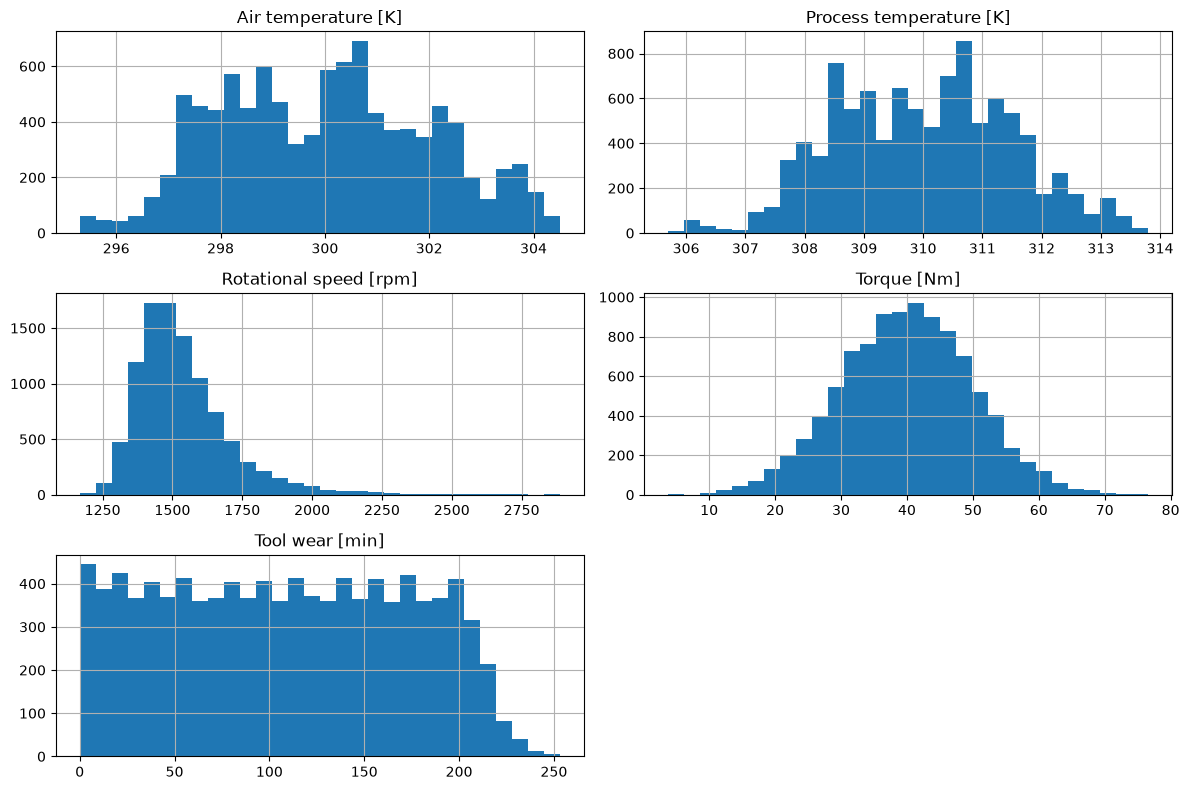

In [34]:
import matplotlib.pyplot as plt

numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[numeric_cols].hist( figsize=(12,8),bins=30)
plt.tight_layout()
plt.savefig('../reports/histograms_features.png')
plt.show()

#  بررسی رابطه‌ی فیچرهای عددی با ستون هدف (Boxplot بر اساس failure=0/1)

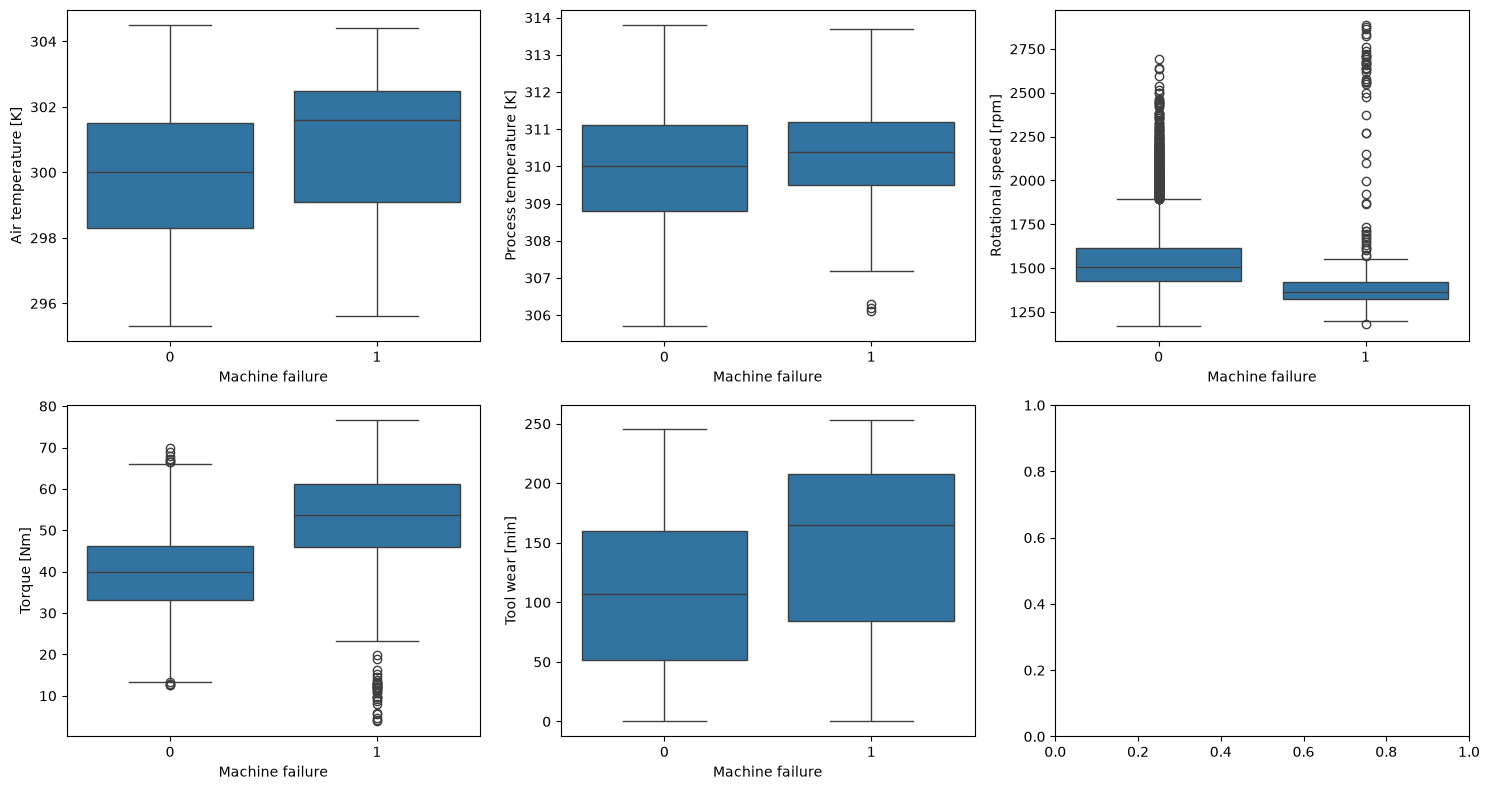

In [45]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3, i % 3]
    sns.boxplot(x='Machine failure', y=col, data=df, ax=ax)
plt.tight_layout()
plt.savefig('../reports/boxplots_by_failure.png')
plt.show()

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

# بررسی همبستگی (Correlation Matrix / Heatmap) بین فیچرها

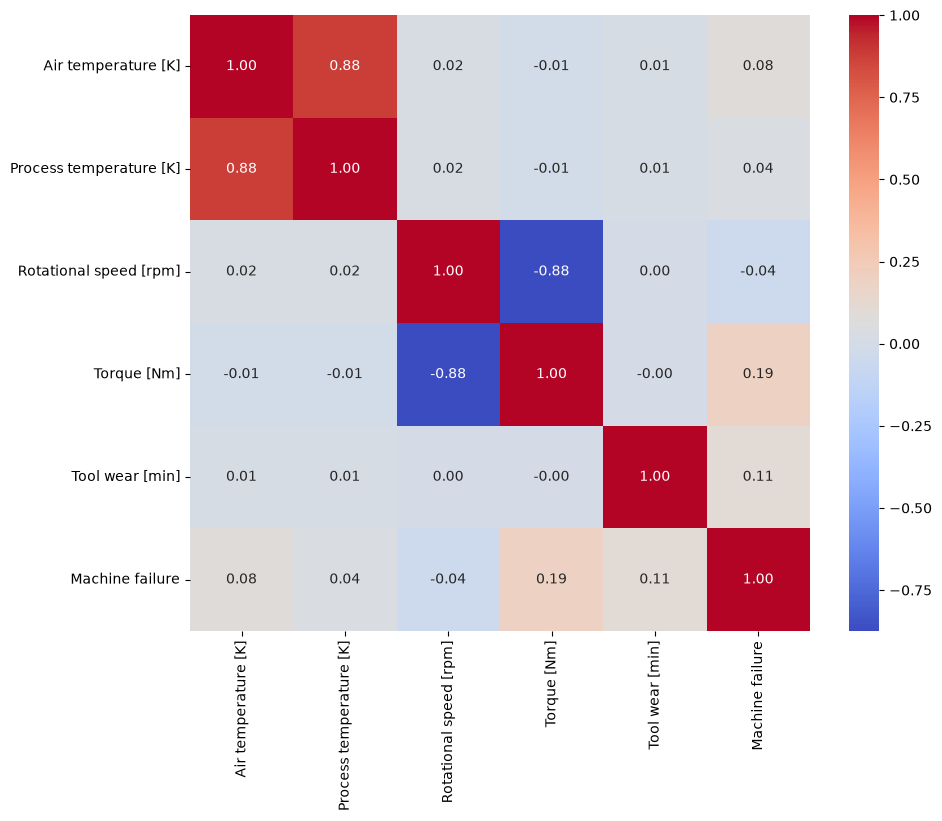

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + ['Machine failure']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

#  بررسی رابطه‌ی ۵ ستون خرابی جزئی (TWF, HDF, PWF, OSF, RNF) با Machine failure

In [52]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for col in failure_types:
    print(f"--- {col} vs Machine failure ---")
    print(pd.crosstab(df[col], df['Machine failure']))
    print()

--- TWF vs Machine failure ---
Machine failure     0    1
TWF                       
0                9661  293
1                   0   46

--- HDF vs Machine failure ---
Machine failure     0    1
HDF                       
0                9661  224
1                   0  115

--- PWF vs Machine failure ---
Machine failure     0    1
PWF                       
0                9661  244
1                   0   95

--- OSF vs Machine failure ---
Machine failure     0    1
OSF                       
0                9661  241
1                   0   98

--- RNF vs Machine failure ---
Machine failure     0    1
RNF                       
0                9643  338
1                  18    1



# بررسی ستون Type (L/M/H) و تأثیرش روی خرابی

In [58]:
print(pd.crosstab(df['Type'], df['Machine failure']))

Machine failure     0    1
Type                      
H                 982   21
L                5765  235
M                2914   83


In [57]:
print(pd.crosstab(df['Type'], df['Machine failure'], normalize='index') * 100)

Machine failure          0         1
Type                                
H                97.906281  2.093719
L                96.083333  3.916667
M                97.230564  2.769436
